In [1]:
import os
import numpy as np

import sys
import os

sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../.."))

In [2]:
# CENTRAL_INDIA_DS = r"L:\My Drive\Central"
# NORTHEASTERN_INDIA_DS = r"G:\My Drive\NorthEastern"
# SOUTHERN_INDIA_DS = r"H:\My Drive\Southern"
# EASTERN_INDIA_DS = r"J:\My Drive\Eastern"
# NORTHERN_INDIA_DS = r"I:\My Drive\Northern"
# WESTERN_INDIA_DS = r"K:\My Drive\Western"

RAW_DS = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\raw_images"

In [3]:
MASK_CLASSES = [3,8,9,10,11]

In [4]:
from services.preproccess import process_scene

c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
OUTPUT_PATCH_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches"

In [6]:
selected_scene = ["scene1","scene2","scene3"]
for scene in selected_scene:
    scene_path = os.path.join(RAW_DS, scene)
    print(f"Checking {scene_path}...")
    if os.path.isdir(scene_path):
        print(f"Processing {scene}...")
        patches = process_scene(scene, scene_path, OUTPUT_PATCH_DIR, MASK_CLASSES)
        print(f"Finished processing {scene}.")

Checking C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\raw_images\scene1...
Processing scene1...
TRANSFORM: | 10.00, 0.00, 600000.00|
| 0.00,-10.00, 2600040.00|
| 0.00, 0.00, 1.00|
EPSG:32645
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 7056
Finished processing scene1.
Checking C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\raw_images\scene2...
Processing scene2...
TRANSFORM: | 10.00, 0.00, 499980.00|
| 0.00,-10.00, 2600040.00|
| 0.00, 0.00, 1.00|
EPSG:32645
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 patches saved...
Total patches saved: 7036
Finished processing scene2.
Checking C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\raw_images\scene3...
Processing scene3...
TRANSFORM: | 10.00, 0.00, 499980.00|
| 0.00,-10.00, 2700000.00|
| 0.00, 0.00, 1.00|
EPSG:32645
1500 patches saved...
3000 patches saved...
4500 patches saved...
6000 pat

In [7]:
import os
import h5py

COUNT = 0
NO_OF_FILES = 0
# ROOT_DS_PATCH_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches"

In [8]:
folder_path = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches"
if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        file = h5py.File(file_path, "r")
        patches = file["patches"]
        COUNT += patches.shape[0]
        NO_OF_FILES += 1

print(f"Total number of patches: {COUNT}")
print(f"Total number of files: {NO_OF_FILES}")

Total number of patches: 21148
Total number of files: 3


In [2]:
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\scene3_patches.h5"

In [3]:
import h5py

file = h5py.File(FILE, "r")
print(list(file.keys()))

['coords', 'indices', 'labels', 'patches']


In [45]:
patches = file["patches"]
coords = file["coords"]
print(patches.shape,coords.shape)

(7056, 6, 256, 256) (7056, 4)


In [46]:
patches[0][0][0]

array([1710., 1714., 1726., 1731., 1684., 1623., 1607., 1637., 1558.,
       1431., 1507., 1512., 1489., 1548., 1511., 1355., 1313., 1390.,
       1482., 1480., 1578., 1644., 1638., 1513., 1531., 1723., 1818.,
       1660., 1446., 1317., 1289., 1311., 1540., 1734., 1737., 1734.,
       1746., 1727., 1702., 1718., 1759., 1706., 1637., 1589., 1602.,
       1684., 1674., 1629., 1630., 1664., 1651., 1632., 1527., 1430.,
       1486., 1448., 1504., 1676., 1640., 1469., 1291., 1413., 1651.,
       1757., 1721., 1637., 1389., 1301., 1425., 1574., 1461., 1406.,
       1612., 1674., 1587., 1581., 1584., 1526., 1518., 1421., 1411.,
       1482., 1446., 1467., 1573., 1609., 1605., 1545., 1500., 1569.,
       1631., 1637., 1559., 1588., 1651., 1554., 1450., 1368., 1302.,
       1274., 1330., 1457., 1493., 1530., 1425., 1337., 1325., 1428.,
       1416., 1279., 1247., 1237., 1261., 1338., 1350., 1324., 1356.,
       1422., 1385., 1543., 1562., 1459., 1557., 1701., 1698., 1598.,
       1490., 1539.,

In [47]:
coords[1000]

array([5.972650e+05, 2.683355e+06, 5.998250e+05, 2.685915e+06],
      dtype=float32)

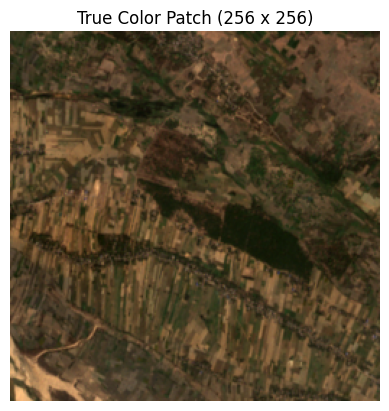

In [58]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

with h5py.File(FILE, "r") as f:
    patch = f["patches"][7000].astype(np.float32)  # convert dtype

# create RGB image
rgb = np.stack([
    patch[2],
    patch[1],
    patch[0]
    
], axis=-1)

# normalize for display
rgb = (rgb - np.nanmin(rgb)) / (np.nanmax(rgb) - np.nanmin(rgb))

plt.imshow(rgb)
plt.title("True Color Patch (256 x 256)")
plt.axis("off")
plt.show()

In [1]:

import numpy as np
import h5py
import os

In [2]:
PATCH_SPECIFIC_DIR = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches"

In [3]:
# patch_path = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\central\scene7_patches.h5"
eps = 1e-6
batch_size = 500

In [ ]:
for fname in os.listdir(PATCH_SPECIFIC_DIR):
    print(f"Processing {fname}...")

    if not fname.endswith("_patches.h5"):
        continue

    patch_path = os.path.join(PATCH_SPECIFIC_DIR, fname)

    with h5py.File(patch_path, "r+") as f:

        patches = f["patches"]
        N, C, H, W = patches.shape

        # remove old indices if exist
        if "indices" in f:
            del f["indices"]

        # float32 dataset
        indices_ds = f.create_dataset(
            "indices",
            shape=(N, 4, H, W),
            dtype=np.float32,
            compression="gzip",
            compression_opts=4,
            chunks=(1, 4, H, W),
        )

        for i in range(0, N, batch_size):

            batch = patches[i:i+batch_size].astype(np.float32)

            B02 = batch[:, 0]
            B04 = batch[:, 2]
            B08 = batch[:, 3]
            B11 = batch[:, 4]
            B12 = batch[:, 5]

            # Indices
            NDVI = (B08 - B04) / (B08 + B04 + eps)
            NDMI = (B08 - B11) / (B08 + B11 + eps)
            CLAY_RATIO = B11 / (B12 + eps)
            BSI = ((B11 - B04) - (B08 - B02)) / ((B11 + B04 + B08 + B02) + eps)

            indices_batch = np.stack(
                [NDVI, NDMI, CLAY_RATIO, BSI],
                axis=1
            )

            # clean invalid values
            indices_batch = np.nan_to_num(
                indices_batch,
                nan=0.0,
                posinf=1.0,
                neginf=-1.0
            )

            # optional clipping (recommended for stability)
            indices_batch = np.clip(indices_batch, -1, 1)


            indices_ds[i:i+batch_size] = indices_batch.astype(np.float32)

            print(f"Processed {i}/{N}")

    print(f"Finished processing {fname}.")


Processing scene1_patches.h5...
Processed 0/7056
Processed 500/7056
Processed 1000/7056
Processed 1500/7056
Processed 2000/7056
Processed 2500/7056
Processed 3000/7056
Processed 3500/7056
Processed 4000/7056
Processed 4500/7056
Processed 5000/7056
Processed 5500/7056
Processed 6000/7056
Processed 6500/7056
Processed 7000/7056
Finished processing scene1_patches.h5.
Processing scene2_patches.h5...
Processed 0/7036
Processed 500/7036
Processed 1000/7036
Processed 1500/7036
Processed 2000/7036
Processed 2500/7036
Processed 3000/7036
Processed 3500/7036
Processed 4000/7036
Processed 4500/7036
Processed 5000/7036
Processed 5500/7036
Processed 6000/7036
Processed 6500/7036
Processed 7000/7036
Finished processing scene2_patches.h5.
Processing scene3_patches.h5...
Processed 0/7056
Processed 500/7056
Processed 1000/7056
Processed 1500/7056
Processed 2000/7056
Processed 2500/7056
Processed 3000/7056
Processed 3500/7056
Processed 4000/7056
Processed 4500/7056
Processed 5000/7056
Processed 5500/705

In [ ]:
import h5py
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\scene1_patches.h5"
file = h5py.File(FILE, "r")
print(list(file.keys()))

['coords', 'indices', 'patches']


In [6]:
indices = file["indices"]
print(indices.shape)

(7056, 4, 256, 256)


In [17]:
indices[0][0][3]

array([0.53131384, 0.5309234 , 0.53797245, 0.5033383 , 0.4817783 ,
       0.46679536, 0.46718296, 0.5454079 , 0.559633  , 0.5390248 ,
       0.53317535, 0.5219743 , 0.52606803, 0.5331263 , 0.53900117,
       0.545146  , 0.5228656 , 0.5206112 , 0.50672483, 0.50036687,
       0.51275194, 0.53795147, 0.46186605, 0.42498973, 0.42321944,
       0.38404855, 0.27631044, 0.21566358, 0.25583425, 0.21843003,
       0.12476008, 0.12108215, 0.17535314, 0.19101578, 0.1893617 ,
       0.21852261, 0.24246657, 0.3951816 , 0.5497703 , 0.4621018 ,
       0.24072164, 0.225503  , 0.23439099, 0.30027676, 0.31713295,
       0.260573  , 0.23772894, 0.18746772, 0.16198263, 0.17864078,
       0.21501088, 0.377097  , 0.4684618 , 0.4842028 , 0.5115871 ,
       0.5141379 , 0.47515696, 0.43013597, 0.41039565, 0.42602766,
       0.456029  , 0.45322698, 0.42532653, 0.39204097, 0.40325707,
       0.41231307, 0.40671352, 0.38922864, 0.4141013 , 0.42873922,
       0.46563193, 0.35028479, 0.09561174, 0.09275952, 0.21957

##### Dataset labelling and augmentation

In [1]:
import geopandas as gpd
import rasterio

WB_SOIL_REF_MAP = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\reference\soil_map\WB_SOIL_SHP.shp"

In [2]:
shp = gpd.read_file(WB_SOIL_REF_MAP)
shp = shp.to_crs("EPSG:32645")

In [3]:
print(shp["soil_class"].unique())

<StringArray>
[ 'Cambisols',      'Other',   'Nitisols',   'Acrisols',   'Regosols',
   'Gleysols',  'Fluvisols',   'Luvisols',   'Lixisols', 'Solonchaks']
Length: 10, dtype: str


In [4]:
SOIL_CLASSES = [
    "Cambisols",
    "Nitisols",
    "Acrisols",
    "Regosols",
    "Gleysols",
    "Fluvisols",
    "Luvisols",
    "Lixisols",
    "Solonchaks",
    "Other"
]

In [5]:
soil_to_id = {soil: i for i, soil in enumerate(SOIL_CLASSES)}
soil_to_id

{'Cambisols': 0,
 'Nitisols': 1,
 'Acrisols': 2,
 'Regosols': 3,
 'Gleysols': 4,
 'Fluvisols': 5,
 'Luvisols': 6,
 'Lixisols': 7,
 'Solonchaks': 8,
 'Other': 9}

In [37]:
import json
import os

save_path = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\metadata\soil_to_id.json"

# create folder if not exists
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, "w") as f:
    json.dump(soil_to_id, f, indent=4)

print("Saved successfully")

Saved successfully


In [6]:
from shapely.geometry import box 
import numpy as np

In [33]:
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\scene3_patches.h5"

In [34]:
import h5py

with h5py.File(FILE, "r") as f:
    coords = f["coords"][:]   # or "coordinates" depending on your key

print(coords.shape)

(7056, 4)


In [35]:
patch_polygons = [box(xmin, ymin, xmax, ymax) for xmin, ymin, xmax, ymax in coords]

gdf_patches = gpd.GeoDataFrame(
    {"patch_id": np.arange(len(patch_polygons))},
    geometry=patch_polygons,
    crs="EPSG:32645"
)

In [36]:
intersection = gpd.overlay(gdf_patches, shp, how="intersection")

In [37]:
intersection["area"] = intersection.geometry.area

In [38]:
labels = np.full(len(gdf_patches), -1)

for pid in range(len(gdf_patches)):
    subset = intersection[intersection["patch_id"] == pid]

    if subset.empty:
        continue

    # Get soil type with max area
    max_row = subset.loc[subset["area"].idxmax()]
    soil_label = max_row["soil_class"]

    labels[pid] = soil_to_id.get(soil_label,soil_to_id["Other"])


In [39]:
values, counts = np.unique(labels, return_counts=True)

for v, c in zip(values, counts):
    print(f"Label {v}: {c} patches")

Label -1: 1888 patches
Label 0: 255 patches
Label 1: 620 patches
Label 5: 38 patches
Label 6: 1683 patches
Label 7: 2564 patches
Label 9: 8 patches


In [40]:
import h5py

with h5py.File(FILE, "r+") as f:
    if "labels" in f:
        del f["labels"]
    f.create_dataset("labels", data=labels)

In [31]:
import h5py
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\scene2_patches.h5"
file = h5py.File(FILE, "r")
print(list(file.keys()))

['coords', 'indices', 'labels', 'patches']


In [32]:
labels = file["labels"]
print(labels.shape)

(7036,)


#### clean ds


In [33]:
import h5py
import numpy as np

FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\scene2_patches.h5"
OUTPUT_FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\clean_ds\scene2_clean_patches.h5"
BATCH_SIZE = 500

In [34]:
with h5py.File(FILE, "r") as infile, h5py.File(OUTPUT_FILE, "w") as outfile:
    
    patches = infile["patches"]
    indices = infile["indices"]
    labels = infile["labels"]
    coords = infile["coords"]

    N = labels.shape[0]

    # Create empty expandable datasets in output
    out_patches = outfile.create_dataset(
        "patches",
        shape=(0, *patches.shape[1:]),
        maxshape=(None, *patches.shape[1:]),
        dtype=patches.dtype,
        chunks=True,
        compression="gzip",
        compression_opts=4
    )

    out_indices = outfile.create_dataset(
        "indices",
        shape=(0, *indices.shape[1:]),
        maxshape=(None, *indices.shape[1:]),
        dtype=indices.dtype,
        chunks=True,
        compression="gzip",
        compression_opts=4
    )

    out_labels = outfile.create_dataset(
        "labels",
        shape=(0,),
        maxshape=(None,),
        dtype=labels.dtype,
        chunks=True,
        compression="gzip",
        compression_opts=4
    )

    out_coords = outfile.create_dataset(
        "coords",
        shape=(0, coords.shape[1]),
        maxshape=(None, coords.shape[1]),
        dtype=coords.dtype,
        chunks=True,
        compression="gzip",
        compression_opts=4
    )

    write_ptr = 0

    for i in range(0, N, BATCH_SIZE):
        print(f"Processing batch {i} to {i+BATCH_SIZE}")

        batch_slice = slice(i, min(i + BATCH_SIZE, N))

        batch_labels = labels[batch_slice]

        # Mask: keep only valid labels
        mask = batch_labels != -1

        if np.sum(mask) == 0:
            continue

        batch_patches = patches[batch_slice][mask]
        batch_indices = indices[batch_slice][mask]
        batch_labels = batch_labels[mask]
        batch_coords = coords[batch_slice][mask]

        batch_size = batch_labels.shape[0]

        # Resize output datasets
        out_patches.resize(write_ptr + batch_size, axis=0)
        out_indices.resize(write_ptr + batch_size, axis=0)
        out_labels.resize(write_ptr + batch_size, axis=0)
        out_coords.resize(write_ptr + batch_size, axis=0)

        # Write data
        out_patches[write_ptr:write_ptr + batch_size] = batch_patches
        out_indices[write_ptr:write_ptr + batch_size] = batch_indices
        out_labels[write_ptr:write_ptr + batch_size] = batch_labels
        out_coords[write_ptr:write_ptr + batch_size] = batch_coords

        write_ptr += batch_size

print("Filtering complete. Saved to:", OUTPUT_FILE)

Processing batch 0 to 500
Processing batch 500 to 1000
Processing batch 1000 to 1500
Processing batch 1500 to 2000
Processing batch 2000 to 2500
Processing batch 2500 to 3000
Processing batch 3000 to 3500
Processing batch 3500 to 4000
Processing batch 4000 to 4500
Processing batch 4500 to 5000
Processing batch 5000 to 5500
Processing batch 5500 to 6000
Processing batch 6000 to 6500
Processing batch 6500 to 7000
Processing batch 7000 to 7500
Filtering complete. Saved to: C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\clean_ds\scene2_clean_patches.h5


In [35]:
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\clean_ds\scene2_clean_patches.h5"

In [36]:
file = h5py.File(FILE,"r")
labels = file["labels"]
patches = file["patches"]
indices = file["indices"]
coords = file["coords"]

In [37]:
print(labels.shape,patches.shape,indices.shape,coords.shape)

(7036,) (7036, 6, 256, 256) (7036, 4, 256, 256) (7036, 4)


In [38]:
np.unique(labels)

array([0, 5, 6, 7, 9])

##### Trainign 

In [2]:
import h5py
import numpy as np
from sklearn.cluster import KMeans
from pyproj import Transformer
from scipy.spatial.distance import cdist

In [4]:
FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\clean_ds\scene2_clean_patches.h5"
BATCH_SIZE = 500
BUFFER_DISTANCE = 500 

In [4]:
with h5py.File(FILE, "r") as f:
    coords = f["coords"][:]  

print("Total samples:", len(coords))

Total samples: 7036


In [5]:
coords

array([[4.999850e+05, 2.597475e+06, 5.025450e+05, 2.600035e+06],
       [5.012650e+05, 2.597475e+06, 5.038250e+05, 2.600035e+06],
       [5.025450e+05, 2.597475e+06, 5.051050e+05, 2.600035e+06],
       ...,
       [6.036650e+05, 2.491235e+06, 6.062250e+05, 2.493795e+06],
       [6.049450e+05, 2.491235e+06, 6.075050e+05, 2.493795e+06],
       [6.062250e+05, 2.491235e+06, 6.087850e+05, 2.493795e+06]],
      shape=(7036, 4), dtype=float32)

In [6]:
xmin = coords[:, 0]
ymin = coords[:, 1]
xmax = coords[:, 2]
ymax = coords[:, 3]

# center of each patch
x_center = (xmin + xmax) / 2
y_center = (ymin + ymax) / 2

xy = np.stack([x_center, y_center], axis=1)

In [7]:
xy

array([[5.012650e+05, 2.598755e+06],
       [5.025450e+05, 2.598755e+06],
       [5.038250e+05, 2.598755e+06],
       ...,
       [6.049450e+05, 2.492515e+06],
       [6.062250e+05, 2.492515e+06],
       [6.075050e+05, 2.492515e+06]], shape=(7036, 2), dtype=float32)

In [8]:
# Number of clusters (adjust based on dataset size)
n_clusters = max(10, len(xy)//500)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_ids = kmeans.fit_predict(xy)

print("Clusters created:", n_clusters)   

Clusters created: 14


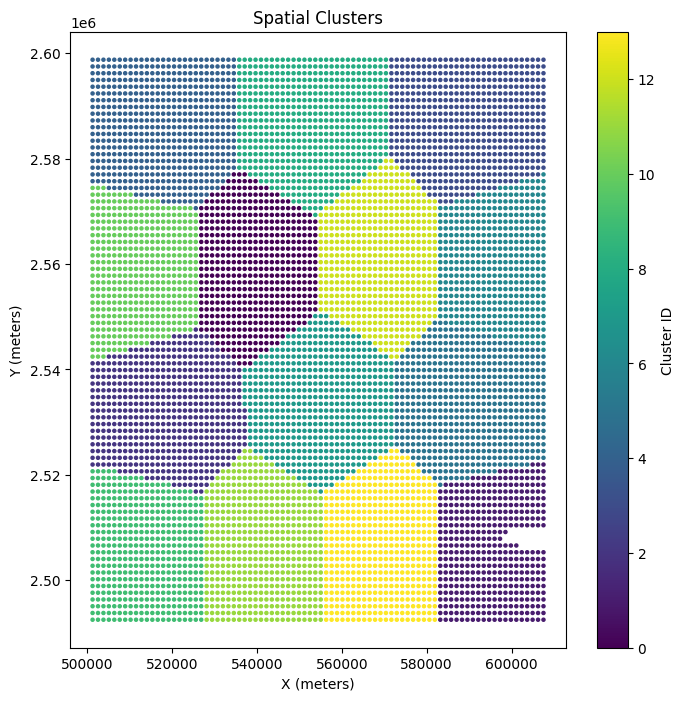

In [9]:
import matplotlib.pyplot as plt

# Plot clusters
plt.figure(figsize=(8, 8))

scatter = plt.scatter(
    xy[:, 0],   # x (meters)
    xy[:, 1],   # y (meters)
    c=cluster_ids,   # cluster labels
    s=5           # small point size for large datasets
)

plt.title("Spatial Clusters")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")

plt.colorbar(scatter, label="Cluster ID")

plt.show()

In [10]:
unique_clusters = np.unique(cluster_ids)
np.random.shuffle(unique_clusters)

n = len(unique_clusters)

train_c = unique_clusters[:int(0.7*n)]
val_c   = unique_clusters[int(0.7*n):int(0.85*n)]
test_c  = unique_clusters[int(0.85*n):]

train_idx = np.isin(cluster_ids, train_c)
val_idx   = np.isin(cluster_ids, val_c)
test_idx  = np.isin(cluster_ids, test_c)

print("Initial split done")

Initial split done


In [11]:
print("Train samples:", np.sum(train_idx))
print("Val samples:", np.sum(val_idx))
print("Test samples:", np.sum(test_idx))

Train samples: 4515
Val samples: 1100
Test samples: 1421


In [12]:
np.unique(test_idx)

array([False,  True])

In [13]:
def apply_buffer(xy, base_mask, other_mask, buffer=500):
    """
    Remove points in other_mask that are closer than 'buffer' meters
    to any point in base_mask
    """
    base_pts = xy[base_mask]
    other_pts = xy[other_mask]

    dist = cdist(other_pts, base_pts)
    keep = dist.min(axis=1) >= buffer

    new_mask = np.zeros_like(other_mask)
    new_mask[np.where(other_mask)[0][keep]] = True

    return new_mask


# Remove val points close to train
val_idx = apply_buffer(xy, train_idx, val_idx, BUFFER_DISTANCE)

# Remove test points close to train + val
test_idx = apply_buffer(xy, train_idx | val_idx, test_idx, BUFFER_DISTANCE)

print("Buffer applied")

Buffer applied


In [14]:
np.unique(val_idx)

array([False,  True])

In [15]:
# print("Train samples:", np.sum(train_idx))
print("Val samples:", np.sum(val_idx))
print("Test samples:", np.sum(test_idx))

Val samples: 1100
Test samples: 1421


In [16]:
# -1 = removed (buffer zone)
# 0 = train, 1 = val, 2 = test

splits = np.full(len(coords), -1)

splits[train_idx] = 0
splits[val_idx]   = 1
splits[test_idx]  = 2

print("Split labels created")

Split labels created


In [17]:
with h5py.File(FILE, "r+") as f:
    patches = f["patches"]
    indices = f["indices"]

    N = patches.shape[0]

    for i in range(0, N, BATCH_SIZE):
        print(f"Processing batch {i} to {i+BATCH_SIZE}")

        # Load batch
        p_batch = patches[i:i+BATCH_SIZE].astype("float32")
        ind_batch = indices[i:i+BATCH_SIZE].astype("float32")

        # --- Normalize bands ---
        p_batch = p_batch / 10000.0

        # --- Normalize indices (per channel) ---
        for c in range(ind_batch.shape[1]):
            mean = ind_batch[:, c].mean()
            std  = ind_batch[:, c].std() + 1e-6
            ind_batch[:, c] = (ind_batch[:, c] - mean) / std

        # --- Handle NaN / Inf ---
        p_batch = np.nan_to_num(p_batch, nan=0.0, posinf=1.0, neginf=0.0)
        ind_batch = np.nan_to_num(ind_batch, nan=0.0, posinf=1.0, neginf=-1.0)

        # Save back
        patches[i:i+BATCH_SIZE] = p_batch
        indices[i:i+BATCH_SIZE] = ind_batch

print("Normalization done (batch-wise)")

Processing batch 0 to 500
Processing batch 500 to 1000
Processing batch 1000 to 1500
Processing batch 1500 to 2000
Processing batch 2000 to 2500
Processing batch 2500 to 3000
Processing batch 3000 to 3500
Processing batch 3500 to 4000
Processing batch 4000 to 4500
Processing batch 4500 to 5000
Processing batch 5000 to 5500
Processing batch 5500 to 6000
Processing batch 6000 to 6500
Processing batch 6500 to 7000
Processing batch 7000 to 7500
Normalization done (batch-wise)


In [18]:
f.close()

In [19]:
print(f)

<Closed HDF5 file>


In [20]:
with h5py.File(FILE, "r+") as f:
    if "split" in f:
        del f["split"]

    f.create_dataset("split", data=splits)

print("Split saved into H5")

Split saved into H5


In [5]:
import h5py
file = h5py.File(FILE, "r")
print(list(file.keys()))

['coords', 'indices', 'labels', 'patches', 'split']


In [18]:
patches = file["patches"]
coords = file["coords"]
indices = file["indices"]
print(patches.shape,indices.shape)

(7036, 6, 256, 256) (7036, 4, 256, 256)


In [26]:
indices[4000][0]

array([[-0.94707644, -0.9636825 , -0.963176  , ..., -0.75067145,
        -0.52865165, -0.5161827 ],
       [-1.0432739 , -0.97368133, -1.0284833 , ..., -0.36612222,
        -0.07661822,  0.02608406],
       [-1.0514905 , -0.9949449 , -1.0752548 , ..., -0.4841649 ,
        -0.18229109,  0.06953119],
       ...,
       [-1.3652489 , -1.1631087 , -1.1632777 , ..., -0.8891007 ,
        -1.0066794 , -1.111752  ],
       [-1.3058289 , -1.1668266 , -1.1354604 , ...,  0.30388758,
        -0.19043906, -0.93867177],
       [-1.2661008 , -1.0975791 , -1.1250739 , ...,  1.4547645 ,
         0.11135766, -0.70647746]], shape=(256, 256), dtype=float32)

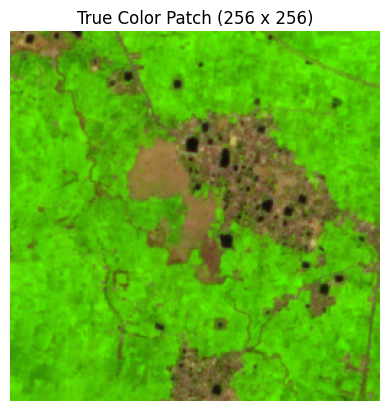

In [9]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

with h5py.File(FILE, "r") as f:
    patch = f["patches"][1000].astype(np.float32)  # convert dtype
    indices = f["indices"][0].astype(np.float32)  # convert dtype

# create RGB image
rgb = np.stack([
    patch[4],
    patch[3],
    patch[2],
    
], axis=-1)

# normalize for display
rgb = (rgb - np.nanmin(rgb)) / (np.nanmax(rgb) - np.nanmin(rgb))

plt.imshow(rgb)
plt.title("True Color Patch (256 x 256)")
plt.axis("off")
plt.show()

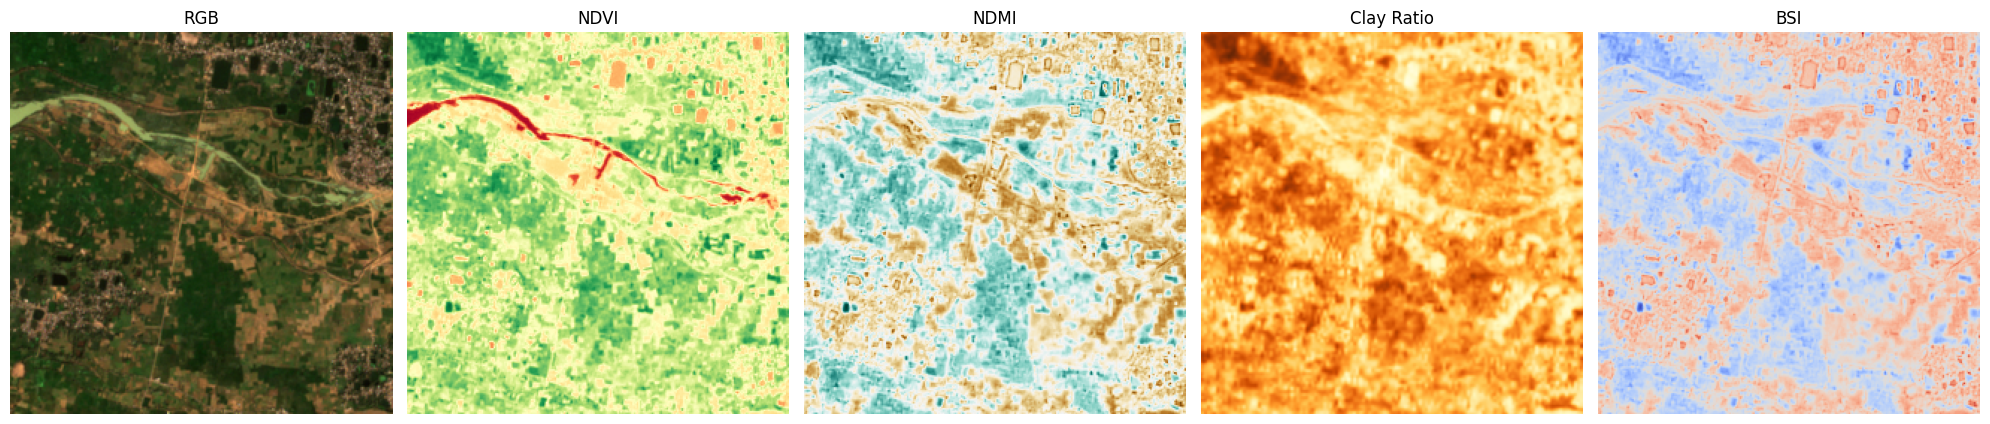

In [ ]:
import matplotlib.pyplot as plt
import h5py
import numpy as np

with h5py.File(FILE, "r") as f:
    patch = f["patches"][2000].astype(np.float32)
    indices = f["indices"][2000].astype(np.float32)

# ----- RGB -----
rgb = np.stack([
    patch[2],  # Red (B04)
    patch[1],  # Green (B03)
    patch[0],  # Blue (B02)
], axis=-1)

rgb = (rgb - np.nanmin(rgb)) / (np.nanmax(rgb) - np.nanmin(rgb) + 1e-6)

# ----- Indices -----
ndvi = indices[0]
ndmi = indices[1]
clay = indices[2]
bsi  = indices[3]

# ----- Plot all (5 images) -----
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# RGB
axes[0].imshow(rgb)
axes[0].set_title("RGB")
axes[0].axis("off")

# NDVI
im1 = axes[1].imshow(ndvi, cmap="RdYlGn")
axes[1].set_title("NDVI")
axes[1].axis("off")

# NDMI
im2 = axes[2].imshow(ndmi, cmap="BrBG")
axes[2].set_title("NDMI")
axes[2].axis("off")

# CLAY RATIO
im3 = axes[3].imshow(clay, cmap="YlOrBr")
axes[3].set_title("Clay Ratio")
axes[3].axis("off")

# BSI
im4 = axes[4].imshow(bsi, cmap="coolwarm")
axes[4].set_title("BSI")
axes[4].axis("off")

plt.tight_layout()
plt.show()

###### clay correction

In [18]:
import h5py
import numpy as np

FILE = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\clean_ds\scene3_clean_patches.h5"
BATCH_SIZE = 500

In [19]:
with h5py.File(FILE, "r+") as f:

    patches_ds = f["patches"]
    indices_ds = f["indices"]

    N = patches_ds.shape[0]

    for i in range(0, N, BATCH_SIZE):
        end = min(i + BATCH_SIZE, N)

        print(f"Processing batch {i} to {end}...")

        #  Load batch only
        patches = patches_ds[i:end]

        # Extract bands
        b11 = patches[:, 4].astype(np.float32)
        b12 = patches[:, 5].astype(np.float32)

        # Compute clay ratio
        clay = b11 / (b12 + 1e-6)
        clay = np.clip(clay, 0, 5)

        #  Directly write into H5 (no full overwrite)
        indices_ds[i:end, 2, :, :] = clay

print("CLAY_RATIO batch-wise updated")

Processing batch 0 to 500...
Processing batch 500 to 1000...
Processing batch 1000 to 1500...
Processing batch 1500 to 2000...
Processing batch 2000 to 2500...
Processing batch 2500 to 3000...
Processing batch 3000 to 3500...
Processing batch 3500 to 4000...
Processing batch 4000 to 4500...
Processing batch 4500 to 5000...
Processing batch 5000 to 5168...
CLAY_RATIO batch-wise updated


In [20]:
file = h5py.File(FILE, "r")
print(list(file.keys()))

['coords', 'indices', 'labels', 'patches', 'split']


In [39]:
patches = file["patches"]
coords = file["coords"]
indices = file["indices"]
labels = file["labels"]
split = file["split"]

In [40]:
print(
    patches.shape,
    coords.shape,
    indices.shape,
    labels.shape,
    split.shape
)

(5168, 6, 256, 256) (5168, 4) (5168, 4, 256, 256) (5168,) (5168,)


> Model training

In [2]:
from services.model import MultiH5Dataset, HybridModel, FocalLoss
from services.utils import compute_class_weights
from torch.utils.data import DataLoader
import torch
import glob

In [4]:
h5_files = glob.glob(r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\dataset\patches\clean_ds\*.h5")

In [5]:
train_ds = MultiH5Dataset(h5_files, split="train")
val_ds   = MultiH5Dataset(h5_files, split="val")
test_ds = MultiH5Dataset(h5_files, split="test")

In [6]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=4)
val_loader   = DataLoader(val_ds, batch_size=16)

In [7]:
from tqdm import tqdm
import h5py

labels = []

for file_path in tqdm(h5_files, desc="Reading H5 files"):
    with h5py.File(file_path, "r") as f:
        splits = f["split"][:]     # (N,)
        lbls   = f["labels"][:]   # (N,)

        train_mask = (splits == 0)   # train = 0

        labels.extend(lbls[train_mask])

Reading H5 files: 100%|██████████| 3/3 [00:00<00:00, 179.90it/s]


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class_weights = compute_class_weights(labels).to(device)

In [9]:
model = HybridModel(num_classes=len(set(labels))).to(device)

c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
criterion = FocalLoss(alpha=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
from tqdm import tqdm

for epoch in range(20):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/20 [Train]")

    for x, y in loop:
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
    
        loss = criterion(pred, y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    scheduler.step()

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1} Train Loss: {avg_loss:.4f}")

Epoch 1/20 [Train]:   0%|          | 0/770 [00:00<?, ?it/s]